In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, classification_report, roc_curve, auc, roc_auc_score
from tqdm import tqdm
tqdm.pandas()

In [5]:
df = pd.read_csv('C:/Users/igrew/OneDrive/Desktop/Course Work/Datasets/full_dataset_detector.csv')
df.head()

,text,label
0,"Оголошення, які поширюють на під’їздах будинкі...",0.0
1,"РФ обстрілює Україну, а вибухонебезпечними пре...",0.0
2,"Російські медіа заявляють, мовляв, у країнах Є...",1.0
3,США змушують Україну звільнити Херсон до вибор...,1.0
4,українські військові прикриваються мирним насе...,1.0


In [6]:
nans = df.isnull().sum()
print(f"Number of nans: \n{nans}")

df = df.dropna()
print(f"\nПісля видалення NaN: {len(df)} рядків")

Number of nans: 
text     0
label    1
dtype: int64

Після видалення NaN: 14118 рядків


In [7]:
df['label'] = 1 - df['label']
print(df.head())
true_count = (df['label'] == 1).sum()
fake_count = (df['label'] == 0).sum()
print(f"Number of true news: {true_count}")
print(f"Number of fake news: {fake_count}")

                                                text  label
0  Оголошення, які поширюють на під’їздах будинкі...    1.0
1  РФ обстрілює Україну, а вибухонебезпечними пре...    1.0
2  Російські медіа заявляють, мовляв, у країнах Є...    0.0
3  США змушують Україну звільнити Херсон до вибор...    0.0
4  українські військові прикриваються мирним насе...    0.0
Number of true news: 7059
Number of fake news: 7059


In [8]:
with open('../stopwords_ua.txt', 'r', encoding='utf-8') as f:
    content = f.read()
    stopwords = content.strip().split()
print(stopwords[:10])

['а', 'аби', 'абиде', 'абиким', 'абикого', 'абиколи', 'абикому', 'абикуди', 'абихто', 'абичий']


In [9]:
text = df.drop(columns='label', axis=1)

def filtering(sentence):
    clean_text = sentence.lower()
    clean_text = re.sub(r'[^\w\s]', '', clean_text)
    words = clean_text.split()
    clean_text = [word for word in words if word not in stopwords]
    return ' '.join(clean_text)
text['text'] = text['text'].progress_apply(filtering)
text

  0%|          | 0/14118 [00:00<?, ?it/s]

100%|██████████| 14118/14118 [00:16<00:00, 854.93it/s] 


,text
0,оголошення поширюють підїздах будинків повістк...
1,рф обстрілює україну вибухонебезпечними предме...
2,російські медіа заявляють мовляв країнах єс зб...
3,сша змушують україну звільнити херсон виборів ...
4,українські військові прикриваються мирним насе...
...,...
14114,житель іванофранківська велосипеді підкорив за...
14115,31 липня тсн розпочне спецпроєкт присвячений 3...
14116,легендарного італійського співака пласідо домі...
14117,вінницька область повітряна тривогакропивницьк...


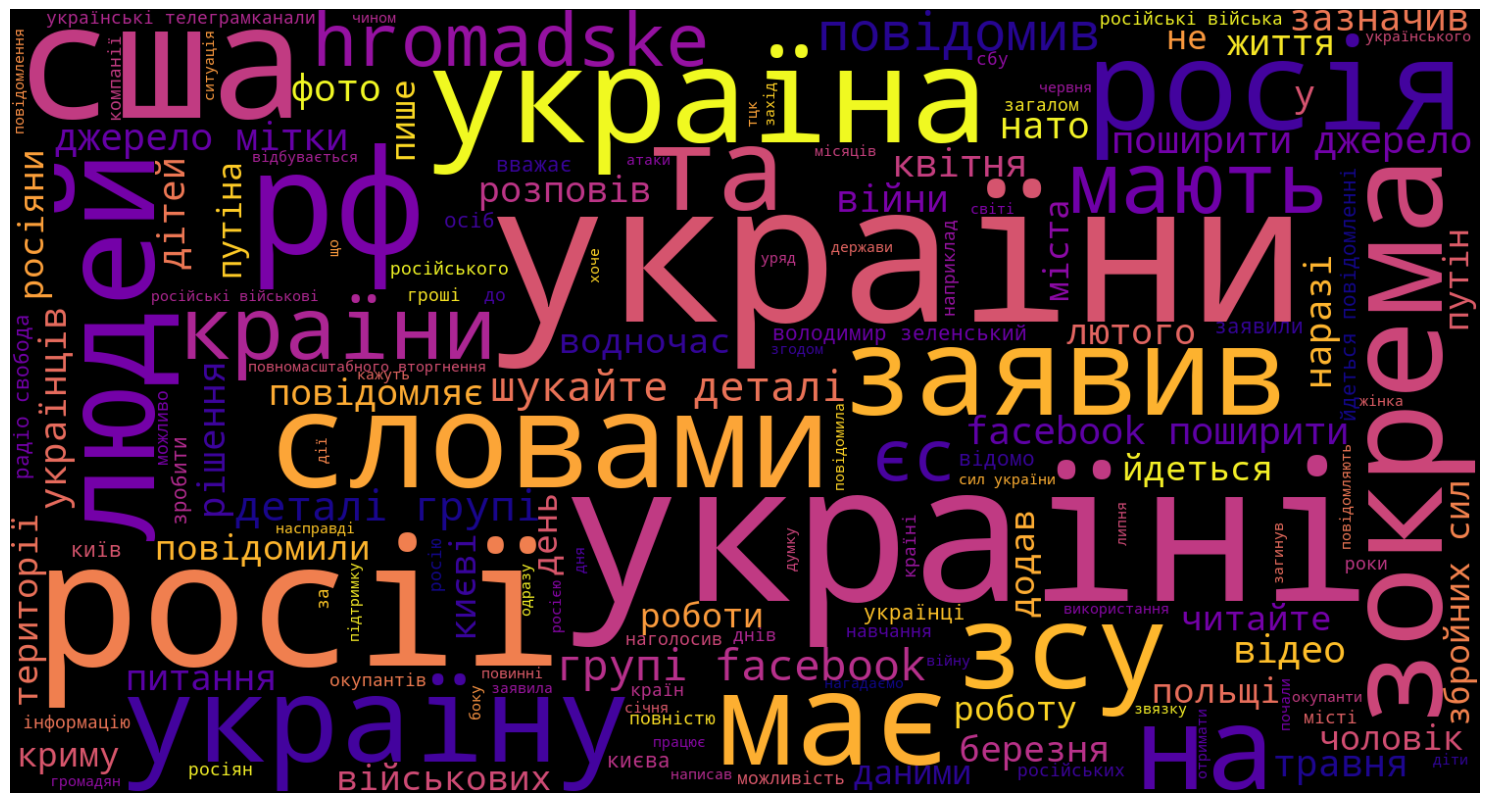

In [10]:
text_for_wordcloud = ' '.join(text['text'])
wordcloud = WordCloud(
    width=1500, 
    height=800, 
    max_words=150, 
    background_color='black',
    min_font_size=10,
    max_font_size=200,
    prefer_horizontal=0.7,
    colormap='plasma'
    )
wordcloud.generate(text_for_wordcloud)
plt.figure(figsize=(15,10))
plt.axis(False)
plt.tight_layout()
plt.imshow(wordcloud, interpolation='bilinear')

In [11]:
morph = pymorphy3.MorphAnalyzer(lang='uk')

def lemmatize_text(content):
    words = content.split()
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return ' '.join(lemmas)

print(f"Before filtering: {df['text'].iloc[0]}")

text['text'] = text['text'].progress_apply(lemmatize_text)

print(f"After filtering: {text['text'].iloc[0]}")

all_words_before = ' '.join(df['text']).split()
all_words_after = ' '.join(text['text']).split()
unique_words_before_filtering = len(set(all_words_before))
unique_words_after_filtering = len(set(all_words_after))
print(f"Unique words before filtering: {unique_words_before_filtering}")
print(f"Unique words after filtering: {unique_words_after_filtering}")
decrease_percent = (unique_words_before_filtering - unique_words_after_filtering) / unique_words_before_filtering * 100
print(f"Decreased by {decrease_percent:.2f}%")

Before filtering: Оголошення, які поширюють на під’їздах будинків, — не повістки, а наказ про загальну мобілізацію.


100%|██████████| 14118/14118 [00:51<00:00, 275.12it/s]


After filtering: оголошення поширювати підїздах будинок повістка наказ загальний мобілізація
Unique words before filtering: 181701
Unique words after filtering: 71545
Decreased by 60.62%


In [12]:
X = text['text'].values
Y = df['label'].values
print(X[:5])
print(Y[:5])

['оголошення поширювати підїздах будинок повістка наказ загальний мобілізація'
 'рф обстрілювати україна вибухонебезпечний предмет міна різноманітний боєприпас'
 'російський медіа заявляти мовляти країна єс збільшитися кількість випадок український біженець позбавляти батьківський право забирати дитина'
 'сша змушувати україна звільнити херсон вибори конгрес представити перемога правлячий сила сша заробити підтримка виборець'
 'український військовий прикриватися мирне населення']
[1. 1. 0. 0. 0.]


In [13]:
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (14118,)
Y shape: (14118,)


In [14]:
vectorizer = TfidfVectorizer(
    max_features=7000,  
    ngram_range=(1, 3), 
    min_df=2, 
    max_df=0.9, 
    sublinear_tf=True,
    use_idf=True,
    smooth_idf=True 
)

X = vectorizer.fit_transform(X)
print(f"TF-IDF векторизація завершена: {X.shape[1]} ознак")


TF-IDF векторизація завершена: 7000 ознак


In [15]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 486943 stored elements and shape (14118, 7000)>
  Coords	Values
  (0, 3882)	0.39515643047355614
  (0, 4679)	0.34735528599157545
  (0, 708)	0.2679812111387797
  (0, 4431)	0.36432871764738234
  (0, 3523)	0.3670955544270931
  (0, 2120)	0.3221693102412932
  (0, 3282)	0.2920008710643489
  (0, 2122)	0.44139510359686945
  (1, 5476)	0.1999250130270412
  (1, 3847)	0.36657163557357636
  (1, 6299)	0.1209937975141249
  (1, 908)	0.47061829435175445
  (1, 4738)	0.37530972409006425
  (1, 3363)	0.4020378635895793
  (1, 5511)	0.4434901592751521
  (1, 672)	0.30059739355735243
  (2, 5390)	0.11244259169923068
  (2, 3210)	0.26077147223331004
  (2, 2362)	0.23481708869491344
  (2, 3289)	0.3058279771188835
  (2, 2913)	0.14684169555121307
  (2, 6892)	0.19552344572116098
  (2, 2391)	0.28851722698638815
  (2, 2988)	0.187262743743114
  (2, 1007)	0.24436194729681263
  :	:
  (14117, 5505)	0.1006618952768356
  (14117, 5554)	0.12390592574239652
  (14117, 6

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [17]:
model_detector = LogisticRegression(
    C=2.0, 
    penalty='l2', 
    solver='saga', 
    class_weight='balanced', 
    random_state=42,
    max_iter=2000,  
    tol=1e-4,  
    n_jobs=-1,
    verbose=1
)
print("Модель створено з максимально оптимізованими параметрами")

Модель створено з максимально оптимізованими параметрами


In [18]:
model_detector.fit(X_train, Y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


convergence after 22 epochs took 1 seconds


,penalty,'l2'
,dual,False
,tol,0.0001
,C,2.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [19]:
X_train_prediction = model_detector.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print(f"Accuracy score of the training data: {training_data_accuracy * 100:.2f}%")

Accuracy score of the training data: 92.59%


In [20]:
X_test_prediction = model_detector.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f"Accuracy score of the test data: {test_data_accuracy * 100:.2f}%")

Accuracy score of the test data: 83.43%


In [21]:
print("Classification Report:")
print(classification_report(Y_test, X_test_prediction, target_names=['Fake', 'True']))

Classification Report:
              precision    recall  f1-score   support

        Fake       0.84      0.83      0.83      1412
        True       0.83      0.84      0.83      1412

    accuracy                           0.83      2824
   macro avg       0.83      0.83      0.83      2824
weighted avg       0.83      0.83      0.83      2824



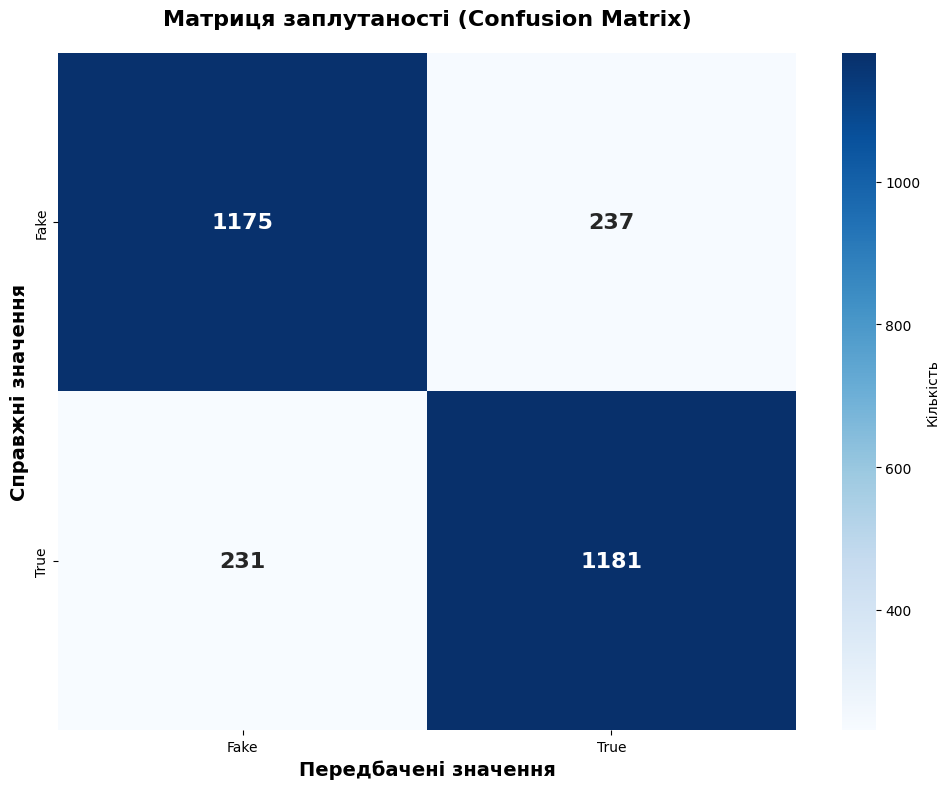


ДЕТАЛЬНА СТАТИСТИКА МАТРИЦІ ЗАПЛУТАНОСТІ
True Negatives (TN): 1175 - правильно визначені FAKE
False Positives (FP): 237 - помилково визначені як TRUE
False Negatives (FN): 231 - помилково визначені як FAKE
True Positives (TP): 1181 - правильно визначені TRUE


In [22]:
import seaborn as sns

cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True'],
    cbar_kws={'label': 'Кількість'},
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title('Матриця заплутаності (Confusion Matrix)', fontsize=16, weight='bold', pad=20)
plt.ylabel('Справжні значення', fontsize=14, weight='bold')
plt.xlabel('Передбачені значення', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ДЕТАЛЬНА СТАТИСТИКА МАТРИЦІ ЗАПЛУТАНОСТІ")
print("="*60)
print(f"True Negatives (TN): {cm[0][0]} - правильно визначені FAKE")
print(f"False Positives (FP): {cm[0][1]} - помилково визначені як TRUE")
print(f"False Negatives (FN): {cm[1][0]} - помилково визначені як FAKE")
print(f"True Positives (TP): {cm[1][1]} - правильно визначені TRUE")
print("="*60)

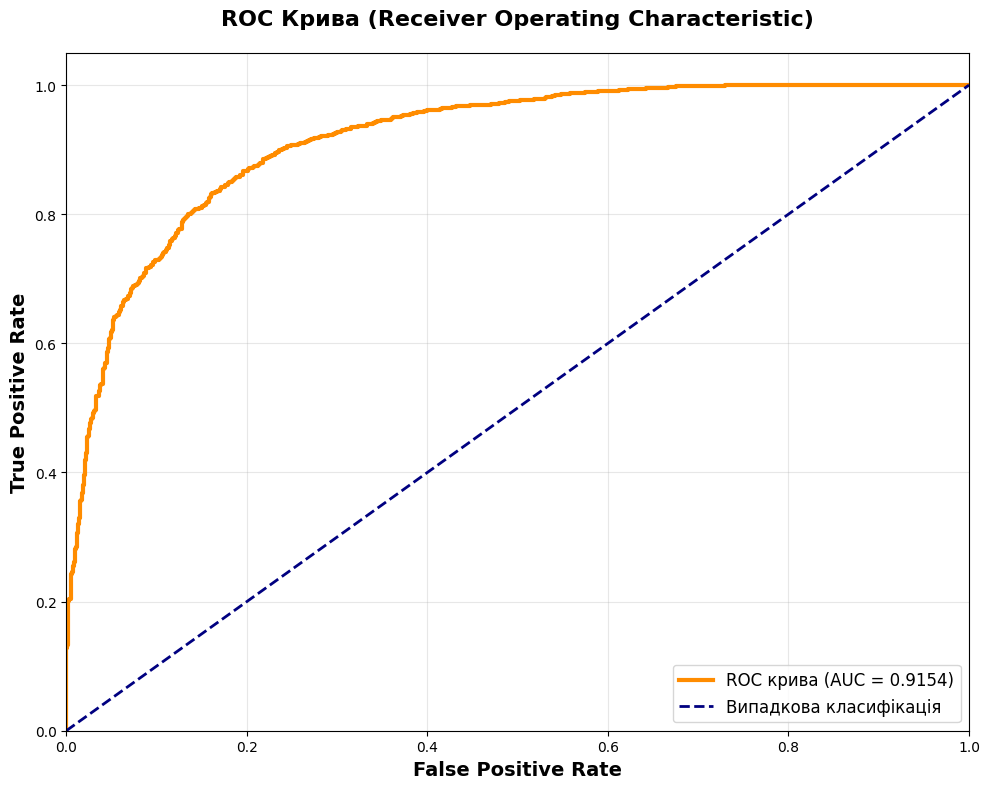


ROC AUC Score: 0.9154
Accuracy: 0.8343
F1-Score: 0.8346


In [23]:
Y_test_proba = model_detector.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC крива (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Випадкова класифікація')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, weight='bold')
plt.ylabel('True Positive Rate', fontsize=14, weight='bold')
plt.title('ROC Крива (Receiver Operating Characteristic)', fontsize=16, weight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Accuracy: {test_data_accuracy:.4f}")
print(f"F1-Score: {f1_score(Y_test, X_test_prediction):.4f}")

In [24]:
input_news = "Компанія Apple анонсувала розробку нового смартфона, який заряджається виключно від звукових хвиль під час розмови власника."

In [25]:
filtered_news = filtering(input_news)
input_text = lemmatize_text(filtered_news)
input_vector = vectorizer.transform([input_text])
prediction = model_detector.predict(input_vector)
prob = model_detector.predict_proba(input_vector)
input_text

'компанія apple анонсувати розробка нове смартфон заряджатися виключно звуковий хвиля розмова власник'

In [26]:
def true_or_false(prob):
    if prob[0][1] > 0.5:
        label = "true"
        probability = prob[0][1]
    else:
        label = "false"
        probability = prob[0][0]
    return label, probability

In [27]:
label, probability = true_or_false(prob)
print(f"News is {label}, with probability {(probability * 100):.2f}%")

News is false, with probability 75.69%


In [28]:
import pickle
with open('fake_true_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('model_detector.pkl', 'wb') as f:
    pickle.dump(model_detector, f)